# ALADIN workflow
This Notebook follow the step-by-step workflow for HW-SW co-design with the proposed framework.

### Imports

In [1]:
import os
import json
import importlib
import numpy as np
import pandas as pd
from importlib import import_module
from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()


while not (p / "ALADIN").exists():   # or any marker file
    if p.parent == p:
        raise RuntimeError("Project root not found")
    p = p.parent
    
os.chdir(os.path.join(p, "ALADIN"))

MODEL_DIR = "./models"

MODELS = [
    "vgg",
    "resnet",
    "mobilenet_v1",
    "shufflenet",
    "efficientnet"
]

target_model = "efficientnet_case 3.onnx"
target_platform = 0


## 1. Implementation-Aware model

In [2]:
import onnx
from qonnx.core.modelwrapper import ModelWrapper

model_path = os.path.join(MODEL_DIR, target_model)
mw = ModelWrapper(onnx.load(model_path))

In [3]:
from qonnx.transformation.infer_shapes import InferShapes
from dory.Frontend_frameworks.QONNX.transformations.aladin_trace_model import ImplementationAwareTrace

mw = mw.transform(InferShapes()) 
mw.transform(ImplementationAwareTrace(
    output_path="./output", 
    file_name=f"STEP1_{target_model.split('.')[0]}",
    verbose=True
))

## 2. Code Generation with Dory

In [4]:
FRONTEND = "QONNX"                  # "NEMO", "Quantlab", "QONNX"
HARDWARE = "PULP.PULP_gvsoc"        # "PULP.GAP8", "PULP.GAP8_L2", "PULP.PULP_gvsoc", "PULP.GAP9", "PULP.GAP9_NE16"
VERBOSE = "None"                    # "None", "Perf_final", "Check_all+Perf_final", "Last+Perf_final"
ISA = "mixed-sw"                    # "auto", "8bit", "mixed-hw", "mixed-sw"

dory_config = {
	"BNRelu_bits": 32,
	"code reserved space": 150000,
    "input_bits": 8,
    "input_signed": False
}

In [5]:
meta_platforms = [
    {
        "num_cores": 8,
        "L1_capacity": 64000,
        "L2_capacity": 512000,
    },
    {
        "num_cores": 4,
        "L1_capacity": 64000,
        "L2_capacity": 320000,
    },
    {
        "num_cores": 2,
        "L1_capacity": 64000,
        "L2_capacity": 256000,
    }
]

In [6]:
onnx_manager = import_module(f"dory.Frontend_frameworks.{FRONTEND}.Parser")
onnx_to_dory = onnx_manager.onnx_manager

graph = onnx_to_dory(
    model_path, 
    dory_config, 
    delta=16
).full_graph_parsing()


###################################
## DORY GENERAL PARSING OF QONNX ##
## FINAL RAPRESENTATION: DORY IR ##
###################################
QONNX conversion complete!
Validation...
Creating Original_graph.onnx in logs/Frontend/onnx_files/
Creating Original_graph.json in logs/Frontend/json_files/
onnx_to_dory net prefix: 

##################################
## DORY GENERAL PARSING OF ONNX ##
## FINAL RAPRESENTATION:DORY IR ##
##################################

Parsing ONNX Graph to create DORY graph.
Creating 00_DORY_raw_graph.json in logs/Frontend/json_files/
Creating 00_DORY_raw_graph.onnx in logs/Frontend/onnx_files/

Embedding constant nodes inside nodes to which the tensors belong.
Creating 01_DORY_graph_constants_removed.json in logs/Frontend/json_files/
Creating 01_DORY_graph_constants_removed.onnx in logs/Frontend/onnx_files/

Quantlab Frontend: Matching patterns from generated ONNX to DORY.

Quantlab Frontend: Updating Add nodes with constants, adding 'conv1d' flags and e

In [7]:
from copy import deepcopy

PLATFORM = meta_platforms[target_platform]

NUM_CORES, L1_capacity, L2_capacity = PLATFORM.values()

onnx_manager = import_module(f'dory.Hardware_targets.{HARDWARE}.HW_Parser')
dory_to_dory_hw = onnx_manager.onnx_manager
graph_tmp = deepcopy(graph)
hw_graph = dory_to_dory_hw(
    graph_tmp,
    n_inputs=1,
    verify_checksum=False,
    L1_capacity=L1_capacity,
    L2_capacity=L2_capacity,
    config_file=dory_config,
    num_cores=NUM_CORES
).full_graph_parsing()

onnx_manager_PULP: Key 'double_buffering' not found in HW_description.json - setting to 2
#####################################################
## DORY GENERAL PARSING FROM DORY IR TO DORY HW IR ##
## FINAL RAPRESENTATION: DORY HW IR                ##
#####################################################
Creating 00_DORY_HW_input_graph.json in logs/HW_related/json_files/
Creating 00_DORY_HW_input_graph.onnx in logs/HW_related/onnx_files/

Backend: Matching patterns from generated DORY ONNX to HW Nodes.
Creating 01_DORY_HW_graph_raw.json in logs/HW_related/json_files/
Creating 01_DORY_HW_graph_raw.onnx in logs/HW_related/onnx_files/

DORY generic Frontend. Updating branches pointers.
Creating 02_DORY_HW_graph_fixed_branches.json in logs/HW_related/json_files/
Creating 02_DORY_HW_graph_fixed_branches.onnx in logs/HW_related/onnx_files/

Updating dimensions of vectors inside the graph, if they do not match among nodes
Creating 03_DORY_HW_graph_fixed_dimensions.json in logs/HW_related/json

In [8]:
onnx_manager = import_module(f'dory.Hardware_targets.{HARDWARE}.C_Parser')
dory_hw_to_c = onnx_manager.C_Parser
dory_hw_to_c(
    hw_graph, 
    dory_config,
    verbose_level=VERBOSE,
    perf_layer="Yes", 
    precision_library=ISA,
    app_directory="./application", 
    model_dir="./models",
    n_inputs=1,
    L1_capacity=L1_capacity,
    L2_capacity=L2_capacity,
    num_cores=NUM_CORES
).full_graph_parsing()

C_Parser_PULP: Key 'double_buffering' not found in HW_description.json - setting to 2
#####################################################
## DORY GENERAL PARSING FROM DORY HW IR TO C FILES ##
## FINAL RAPRESENTATION: COMPILABLE C PROJECT      ##
#####################################################

Generating the .c file of the network.

Generating the Makefile.
Makefile template writer: key 'single_core_dma' not found in HW description, using multi-core transfers!
Makefile template writer: key 'single_core_dma' not found in HW description, using multi-core transfers!

Mapping the layers files to their templates and copying the kernels associated.

Copying Utils.

Generating .hex weight files.
Saved ./application/hex/ReluConvolution0_weights.hex: 224 values, 896 source bytes
Saved ./application/hex/ReluConvolution1_weights.hex: 80 values, 320 source bytes
Saved ./application/hex/ReluConvolution2_weights.hex: 72 values, 288 source bytes
Saved ./application/hex/ReluConvolution4_weight

## 3. Platform-Aware modele

In [9]:

measurement_path = os.path.join(
    "./output",
    f"STEP3_paltform {target_platform+1}_{target_model.split('.')[0]}.csv"
)

try:
    measured_df = pd.read_csv(measurement_path)
    measured_df = measured_df.dropna(subset=["layer_name", "num_cycles"])

    measured_df["layer_name"] = (
        measured_df["layer_name"]
        .astype(str)
        .str.strip()
    )

    measured_df["num_cycles"] = (
        pd.to_numeric(measured_df["num_cycles"], errors="coerce")
    )

    measured_df = measured_df.dropna(subset=["num_cycles"])
    measured_df["num_cycles"] = measured_df["num_cycles"].astype(int)
    measured_cycles = dict(
        zip(
            measured_df["layer_name"],
            measured_df["num_cycles"],
        )
    )
    
except:
    measured_cycles = None

measured_cycles

{'ReluConvolution0': 81408,
 'ReluConvolution1': 53657,
 'ReluConvolution2': 38931,
 'Addition3': 13493,
 'ReluConvolution4': 114668,
 'ReluConvolution5': 80221,
 'ReluConvolution6': 24209,
 'ReluConvolution7': 63247,
 'ReluConvolution8': 100100,
 'ReluConvolution9': 33426,
 'Addition10': 7215,
 'ReluConvolution11': 63331,
 'ReluConvolution12': 46895,
 'ReluConvolution13': 13026,
 'ReluConvolution14': 27243,
 'ReluConvolution15': 47011,
 'ReluConvolution16': 16039,
 'Addition17': 3357,
 'ReluConvolution18': 27256,
 'ReluConvolution19': 20973,
 'ReluConvolution20': 8720,
 'ReluConvolution21': 19223,
 'ReluConvolution22': 30000,
 'ReluConvolution23': 13730,
 'Addition24': 4568,
 'ReluConvolution25': 19229,
 'ReluConvolution26': 14617,
 'ReluConvolution27': 25487,
 'ReluConvolution28': 53282,
 'ReluConvolution29': 21549,
 'ReluConvolution30': 45557,
 'Addition31': 4500,
 'ReluPooling32': 2407,
 'ReluFullyConnected33': 1508}

In [10]:
import dory.Frontend_frameworks.QONNX.transformations.aladin_latency_model as alm



def rt_family(node, r):
    family = alm.classify_node(node, r)
    if str(getattr(node, "implementation", "")).lower() == "lut":
        return "lut"
    
    k = list(getattr(node, "kernel_shape", [1, 1]) or [1, 1])
    s = list(getattr(node, "strides", [1, 1]) or [1, 1])
    
    if family == "standard_conv":
        if k == [1, 1]:
            return "conv_1x1"
        if any(x > 1 for x in s):
            return "conv_spatial_downsample"
        return "conv_spatial"
    
    if family == "depthwise_conv":
        return (
            "depthwise_downsample"
            if any(x > 1 for x in s)
            else "depthwise"
        )
    
    return family



hardware_name = str(HARDWARE).split(".")[-1]

hw_spec_path = (
    Path("./dory")
    / "Hardware_targets"
    / "PULP"
    / hardware_name
    / "HW_description.json"
)

with hw_spec_path.open("r") as handle:
    raw_hw_spec = json.load(handle)

raw_hw_spec["memory"]["L1"]["dimension"] = int(
    L1_capacity
)
raw_hw_spec["memory"]["L2"]["dimension"] = int(
    L2_capacity
)

hw_spec = alm.prepare_pulp_hw_spec(
    raw_hw_spec
)


estimator = alm.LatencyEstimator.simple(
    hw_spec,
    num_cores=int(NUM_CORES),
    generated_code_dir=(
        "./application/DORY_network/src"
    ),
)

estimator.tiling = alm.TilingModelConfig(
    enabled=True,
    level_name="L1",
    compute_mode="full_layer",
    edge_tile_safety_factor=1.0,
    unknown_geometry_compute_factor=1.0,
    unknown_geometry_dma_redundancy_factor=1.05,
    max_dma_redundancy_factor=2.0,
    use_generated_tile_count_first=True,
)

raw_results = estimator.process(hw_graph)

if measured_cycles is None:
    results = raw_results
else:
    RT_RESERVE = 1.02
    ratios = {}

    for node, r in zip(hw_graph, raw_results):
        name = r["name"]

        if name not in measured_cycles:
            continue

        family = rt_family(node, r)

        ratio = float(measured_cycles[name]) / float(r["pessimistic_cycles"])
        ratios[family] = max(ratios.get(family, 0.0), ratio)


    rt_factors = {
        family: ratio * RT_RESERVE
        for family, ratio in ratios.items()
    }

    print("RT factors:")
    for family, factor in rt_factors.items():
        print(f"{family:25s} {factor:.3f}")


    results = []

    for node, r in zip(hw_graph, raw_results):
        result = dict(r)

        family = rt_family(node, r)
        factor = rt_factors.get(family, 1.0)

        result["family"] = family
        result["calibrated_pessimistic_cycles"] = int(
            np.ceil(
                r["pessimistic_cycles"] * factor
            )
        )

        results.append(result)


RT factors:
conv_spatial              0.847
depthwise                 0.846
conv_1x1                  0.968
elementwise_add           0.553
depthwise_downsample      0.937
pooling                   1.189
fully_connected           1.901


In [11]:
df = pd.DataFrame([
    {
        "name": r["name"],
        "latency": alm.get_pessimistic_cycles(r),
    }
    for r in results
])
predicted_latency_path = f"./output/STEP2_{target_model.split('.')[0]}_platform {target_platform+1}_latency.csv"
df.to_csv(predicted_latency_path, index=False)

## 4. GVSoC simulation
*NOTE*: this portion of the notebooks run only inside the container.

In [12]:
import subprocess


cmd =   f"""
        source .devcontainer/pulp_sdk.sh
        export PATH=/dory_env/bin:$PATH
        make -C ./application clean all run platform=gvsoc CORE={NUM_CORES}
        """
try:
    proc = subprocess.run(
        ["bash", "-c", cmd],
        check=True,
        capture_output=True,
        text=True,
        timeout=360,
    )
    
except subprocess.CalledProcessError as e:
    raise RuntimeError(
        f"Build or run failed (exit {e.returncode}):\n"
        f"STDOUT:\n{e.stdout}\n"
        f"STDERR:\n{e.stderr}"
    )
except subprocess.TimeoutExpired as e:
    raise TimeoutError(
        f"Test timed out after 720s.\n"
        f"Partial STDOUT:\n{e.stdout}\n"
        f"STDERR:\n{e.stderr}"
    )
    
proc.stdout

"make: Entering directory '/workspaces/ALADIN/application'\nRM  /workspaces/ALADIN/application/BUILD/PULP/GCC_RISCV/\nCC  src/pulp_nn_depthwise_u8_u8_i8.c\nCC  src/ReluFullyConnected33.c\nCC  src/ReluConvolution11.c\nCC  src/ReluConvolution0.c\nCC  src/ReluConvolution14.c\nCC  src/ReluConvolution20.c\nCC  src/mem.c\nCC  src/ReluConvolution6.c\nCC  src/ReluConvolution13.c\nCC  src/ReluConvolution27.c\nCC  src/pulp_nn_conv_u8_i8_i8.c\nCC  src/ReluConvolution4.c\nCC  src/ReluConvolution19.c\nCC  src/ReluConvolution28.c\nCC  src/main.c\nCC  src/ReluConvolution9.c\nCC  src/dory_dma.c\nCC  src/pulp_nn_matmul_i8_u8_i8.c\nCC  src/ReluConvolution1.c\nCC  src/ReluConvolution23.c\nCC  src/ReluConvolution29.c\nCC  src/pulp_nn_linear_i8_i8_i8.c\nCC  src/ReluConvolution5.c\nCC  src/pulp_nn_matmul_i8_i8_i8.c\nCC  src/ReluConvolution2.c\nCC  src/Addition31.c\nCC  src/Addition10.c\nCC  src/ReluConvolution22.c\nCC  src/ReluConvolution21.c\nCC  src/pulp_nn_add_i8_u8_i8.c\nCC  src/ReluConvolution8.c\nCC  

## Check results:

In [13]:
import csv

csv_path = os.path.join(
    "./output",
    f"STEP3_paltform {target_platform+1}_{target_model.split('.')[0]}.csv"
)
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

In [14]:
with open("./logs/HW_related/json_files/06_DORY_HW_tiled_graph.json", "r") as f:
    layers_tiling_info = json.load(f)["graph"]

In [15]:

def sum_componenets(tile: dict) -> int:
    return sum((
        tile["weight_memory"],
        tile["bias_memory"],
        tile["constants_memory"],
        tile["input_activation_memory"],
        tile["output_activation_memory"],
        tile.get("lut_memory", 0),
    ))
                        


with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "layer_name", 
        "MACs", 
        "num_cycles", 
        "MAC_per_cycle", 
        "num_cores", 
        "L1_mem", 
        "L2_mem", 
        "L1_tiling", 
        "L2_tiling"
    ])
    idx = 0
    for line in proc.stdout.splitlines():
        if not line.startswith("PERF_LOG"):
            continue
            
        info = line.strip().split(",")
        if len(info) != 6:
            continue
        
        _, layer_name, macs, cycles, perf, cores = info
        tiling_info = layers_tiling_info[idx]["Tiling_parameters"]
        idx += 1
        writer.writerow([
            layer_name,
            int(macs),
            int(cycles),
            float(perf),
            int(cores),
            L1_capacity,
            L2_capacity,
            sum_componenets(tiling_info["L1"]),
            sum_componenets(tiling_info["L2"])
        ])

MAPE: 63.06%
Safety coverage: 100.00%
Worst safety margin: 2.00%
Median safety margin: 34.07%
Maximum underestimation: 0.00% (None)
Maximum overestimation: 182.13% (ReluConvolution23)


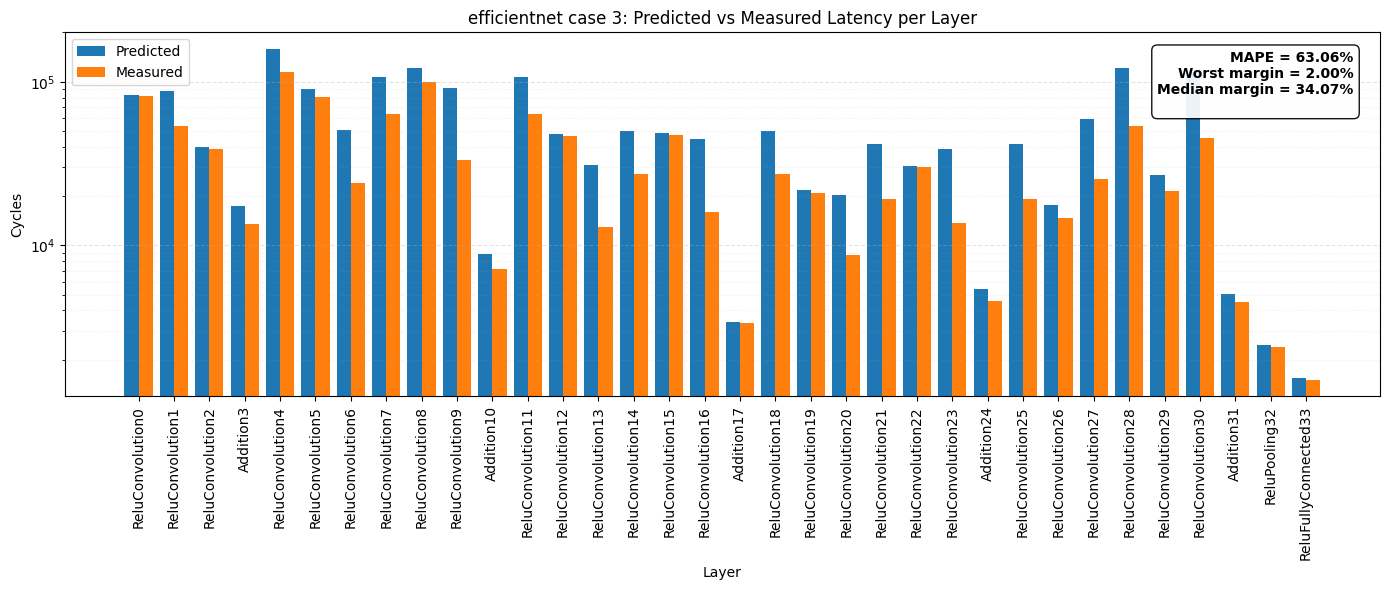

In [16]:
import matplotlib.pyplot as plt



predicted = pd.read_csv(predicted_latency_path).rename(columns={"latency": "predicted_latency"})
measured = pd.read_csv(csv_path).rename(columns={"layer_name": "name", "num_cycles": "measured_latency"})

comparison = predicted.merge(measured[["name", "measured_latency"]], on="name", how="inner")
comparison[["predicted_latency", "measured_latency"]] = comparison[["predicted_latency", "measured_latency"]].apply(pd.to_numeric, errors="coerce")
comparison = comparison.dropna(subset=["predicted_latency", "measured_latency"]).query("measured_latency > 0").reset_index(drop=True)

comparison["margin_pct"] = (comparison["predicted_latency"] - comparison["measured_latency"]) / comparison["measured_latency"] * 100
comparison["safe"] = comparison["predicted_latency"] >= comparison["measured_latency"]

mape = comparison["margin_pct"].abs().mean()
safety_coverage = comparison["safe"].mean() * 100.0
worst_margin = comparison["margin_pct"].min()
median_margin = comparison["margin_pct"].median()
max_underestimation = max(0.0, -worst_margin)
max_overestimation = max(0.0, comparison["margin_pct"].max())
worst_under_layer = comparison.loc[comparison["margin_pct"].idxmin(), "name"] if worst_margin < 0 else "None"
worst_over_layer = comparison.loc[comparison["margin_pct"].idxmax(), "name"] if max_overestimation > 0 else "None"

print(f"MAPE: {mape:.2f}%")
print(f"Safety coverage: {safety_coverage:.2f}%")
print(f"Worst safety margin: {worst_margin:.2f}%")
print(f"Median safety margin: {median_margin:.2f}%")
print(f"Maximum underestimation: {max_underestimation:.2f}% ({worst_under_layer})")
print(f"Maximum overestimation: {max_overestimation:.2f}% ({worst_over_layer})")

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comparison))
width = 0.4
ax.bar(x - width/2, comparison["predicted_latency"], width, label="Predicted")
ax.bar(x + width/2, comparison["measured_latency"], width, label="Measured")
ax.set(xticks=x, ylabel="Cycles", xlabel="Layer", title=f"{target_model.split('.')[0].replace('_', ' ')}: Predicted vs Measured Latency per Layer")
ax.set_xticklabels(comparison["name"], rotation=90)
ax.set_yscale("log")
ax.grid(axis="y", which="major", linestyle="--", alpha=0.35)
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.20)
ax.legend()

metrics_text = f"MAPE = {mape:.2f}%\nWorst margin = {worst_margin:.2f}%\nMedian margin = {median_margin:.2f}%\n"
ax.text(0.98, 0.95, metrics_text, transform=ax.transAxes, ha="right", va="top", fontsize=10, fontweight="bold", 
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.92, edgecolor="black"))
plt.tight_layout()
plt.show()